# Bucket Stage Deep Dive

This notebook inspects the exact bucketed dataset used for stage-2 training.

Focus areas:
- bucket composition by qubit count and gate/time length
- purity and heterogeneity inside buckets
- prompt / SRV diversity inside buckets
- similarity of circuits within buckets
- comparison between prepared dataset, train split, and valid split


In [1]:
import os
import sys
from pathlib import Path
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from IPython.display import display

from notebooks.bucket_deep_dive_helper import (
    DEFAULT_DATASET_ROOT,
    DEFAULT_TRAINING_CFG,
    load_and_summarize_bucket_stage,
    maybe_dataframe,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11


In [2]:
DATASET_ROOT = Path(DEFAULT_DATASET_ROOT)
TRAINING_CFG = Path(DEFAULT_TRAINING_CFG)
DEVICE = "cpu"
BATCH_SIZE = None
SPLIT_RATIO = 0.1
SEED = 1234
MODEL_SCALE_FACTOR = 4
SIMILARITY_MAX_BUCKETS = 300
SIMILARITY_SAMPLE_SIZE = 24

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATASET_ROOT =", DATASET_ROOT)
print("TRAINING_CFG =", TRAINING_CFG)

if not DATASET_ROOT.exists():
    raise FileNotFoundError(
        f"Dataset root does not exist: {DATASET_ROOT}\n"
        "Point DATASET_ROOT to the dataset actually used during stage-2 training."
    )


PROJECT_ROOT = /workspace/qcircuit-generation
DATASET_ROOT = /workspace/qcircuit-generation/datasets/qc_srv_dataset_3to8qubit
TRAINING_CFG = /workspace/qcircuit-generation/conf/training/paper_stage_2.yaml


In [3]:
analysis = load_and_summarize_bucket_stage(
    DATASET_ROOT,
    training_cfg_path=TRAINING_CFG,
    batch_size=BATCH_SIZE,
    split_ratio=SPLIT_RATIO,
    seed=SEED,
    model_scale_factor=MODEL_SCALE_FACTOR,
    similarity_max_buckets=SIMILARITY_MAX_BUCKETS,
    similarity_sample_size=SIMILARITY_SAMPLE_SIZE,
    device=DEVICE,
)

print("LOADER CFG")
pprint(analysis["loader_cfg"])


2026-03-26 09:00:31 - quantum_diffusion.data.dataset - INFO - Detected preprocessed dataset. Loading directly...
[INFO]: Loading tensor from `/workspace/qcircuit-generation/datasets/qc_srv_dataset_3to8qubit/dataset/ds_x.pt` onto device: cpu.
[INFO]: Loading tensor from `/workspace/qcircuit-generation/datasets/qc_srv_dataset_3to8qubit/dataset/ds_y.pt` onto device: cpu.
[INFO]: Loading tensor from `/workspace/qcircuit-generation/datasets/qc_srv_dataset_3to8qubit/dataset/ds_z.pt` onto device: cpu.
[INFO]: Instantiated config_dataset from given config on cpu.
2026-03-26 09:00:39 - quantum_diffusion.data.dataset - INFO - Dataset loaded from /workspace/qcircuit-generation/datasets/qc_srv_dataset_3to8qubit


  0%|          | 0/1 [00:00<?, ?it/s]

 - balance_tensor_dataset, njobs=1, number of samples=2463286
 - uniquify_tensor_dataset, number of samples now 2463286
 - balancing


  0%|          | 0/471 [00:00<?, ?it/s]

 - dataset size after balancing 2463286
Split: Train 9141 - Test 481 

2026-03-26 09:01:05 - quantum_diffusion.data.dataset - INFO - Datasets combined into a mixed dataset
[INFO]: Not balancing dataset!  balance_max=None
LOADER CFG
{'training': {'batch_size': 256, 'padding_mode': 'bucket'}}


In [4]:
try:
    import pandas as pd
except Exception:
    pd = None

prepared_df = maybe_dataframe(analysis["prepared"]["bucket_rows"])
train_df = maybe_dataframe(analysis["train"]["bucket_rows"])
valid_df = maybe_dataframe(analysis["valid"]["bucket_rows"])

prepared_sim_df = maybe_dataframe(analysis["prepared"]["similarity_rows"])
train_sim_df = maybe_dataframe(analysis["train"]["similarity_rows"])
valid_sim_df = maybe_dataframe(analysis["valid"]["similarity_rows"])

def as_df(obj):
    if pd is None:
        raise RuntimeError("pandas is required for this notebook.")
    return obj if isinstance(obj, pd.DataFrame) else pd.DataFrame(obj)

prepared_df = as_df(prepared_df)
train_df = as_df(train_df)
valid_df = as_df(valid_df)
prepared_sim_df = as_df(prepared_sim_df)
train_sim_df = as_df(train_sim_df)
valid_sim_df = as_df(valid_sim_df)

def pair_rows_to_df(rows):
    data = []
    for row in rows:
        left, right = row["pair"]
        data.append({"left": int(left), "right": int(right), "count": int(row["count"])})
    return pd.DataFrame(data)

prepared_q_pair_df = pair_rows_to_df(analysis["prepared"]["sample_pair_counts"]["z_vs_actual_qubits"])
prepared_t_pair_df = pair_rows_to_df(analysis["prepared"]["sample_pair_counts"]["z_vs_actual_time"])
train_q_pair_df = pair_rows_to_df(analysis["train"]["sample_pair_counts"]["z_vs_actual_qubits"])
train_t_pair_df = pair_rows_to_df(analysis["train"]["sample_pair_counts"]["z_vs_actual_time"])
valid_q_pair_df = pair_rows_to_df(analysis["valid"]["sample_pair_counts"]["z_vs_actual_qubits"])
valid_t_pair_df = pair_rows_to_df(analysis["valid"]["sample_pair_counts"]["z_vs_actual_time"])


In [5]:
overview = pd.DataFrame([
    {
        "split": "prepared",
        "bucket_count": len(prepared_df),
        "mean_qubit_purity": prepared_df["qubit_majority_ratio"].mean(),
        "mean_time_purity": prepared_df["time_majority_ratio"].mean(),
        "mean_prompt_unique": prepared_df["prompt_unique_count"].mean(),
        "mean_srv_unique": prepared_df["srv_unique_count"].mean(),
        "mean_ent_bucket_unique": prepared_df["ent_bucket_unique_count"].mean(),
        "mismatch_qubit_max_buckets": int((~prepared_df["qubit_matches_z_max"]).sum()),
        "mismatch_time_max_buckets": int((~prepared_df["time_matches_z_max"]).sum()),
    },
    {
        "split": "train",
        "bucket_count": len(train_df),
        "mean_qubit_purity": train_df["qubit_majority_ratio"].mean(),
        "mean_time_purity": train_df["time_majority_ratio"].mean(),
        "mean_prompt_unique": train_df["prompt_unique_count"].mean(),
        "mean_srv_unique": train_df["srv_unique_count"].mean(),
        "mean_ent_bucket_unique": train_df["ent_bucket_unique_count"].mean(),
        "mismatch_qubit_max_buckets": int((~train_df["qubit_matches_z_max"]).sum()),
        "mismatch_time_max_buckets": int((~train_df["time_matches_z_max"]).sum()),
    },
    {
        "split": "valid",
        "bucket_count": len(valid_df),
        "mean_qubit_purity": valid_df["qubit_majority_ratio"].mean(),
        "mean_time_purity": valid_df["time_majority_ratio"].mean(),
        "mean_prompt_unique": valid_df["prompt_unique_count"].mean(),
        "mean_srv_unique": valid_df["srv_unique_count"].mean(),
        "mean_ent_bucket_unique": valid_df["ent_bucket_unique_count"].mean(),
        "mismatch_qubit_max_buckets": int((~valid_df["qubit_matches_z_max"]).sum()),
        "mismatch_time_max_buckets": int((~valid_df["time_matches_z_max"]).sum()),
    },
])

display(overview)


,split,bucket_count,mean_qubit_purity,mean_time_purity,mean_prompt_unique,mean_srv_unique,mean_ent_bucket_unique,mismatch_qubit_max_buckets,mismatch_time_max_buckets
0,prepared,9141,0.991020,0.198725,1.049119,0.0,0.0,0,0
1,train,8227,0.991246,0.198723,1.048256,0.0,0.0,0,0
2,valid,914,0.988982,0.198744,1.056893,0.0,0.0,0,0


In [6]:
def plot_pair_heatmap(df, *, title, xlabel, ylabel, ax, normalize=False):
    left_vals = sorted(df["left"].unique())
    right_vals = sorted(df["right"].unique())
    left_index = {v: i for i, v in enumerate(left_vals)}
    right_index = {v: i for i, v in enumerate(right_vals)}
    mat = np.zeros((len(left_vals), len(right_vals)), dtype=float)
    for row in df.itertuples(index=False):
        mat[left_index[row.left], right_index[row.right]] = row.count
    if normalize and mat.sum() > 0:
        mat = mat / mat.sum()
    im = ax.imshow(mat, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(right_vals)))
    ax.set_xticklabels(right_vals)
    ax.set_yticks(range(len(left_vals)))
    ax.set_yticklabels(left_vals)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

def plot_hist_compare(series_map, *, bins, title, xlabel, ax):
    for label, values in series_map.items():
        ax.hist(values, bins=bins, alpha=0.45, label=label)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Bucket count")
    ax.legend()

def plot_box_by_qubits(df, column, *, title, ylabel, ax):
    qubits = sorted(df["z_max_qubits"].unique())
    data = [df.loc[df["z_max_qubits"] == q, column].values for q in qubits]
    ax.boxplot(data, labels=qubits, showfliers=False)
    ax.set_title(title)
    ax.set_xlabel("z max qubits")
    ax.set_ylabel(ylabel)


## Prepared Dataset: Bucket Composition

/tmp/ipykernel_15648/823483770.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=qubits, showfliers=False)
/tmp/ipykernel_15648/823483770.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=qubits, showfliers=False)
/tmp/ipykernel_15648/823483770.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=qubits, showfliers=False)


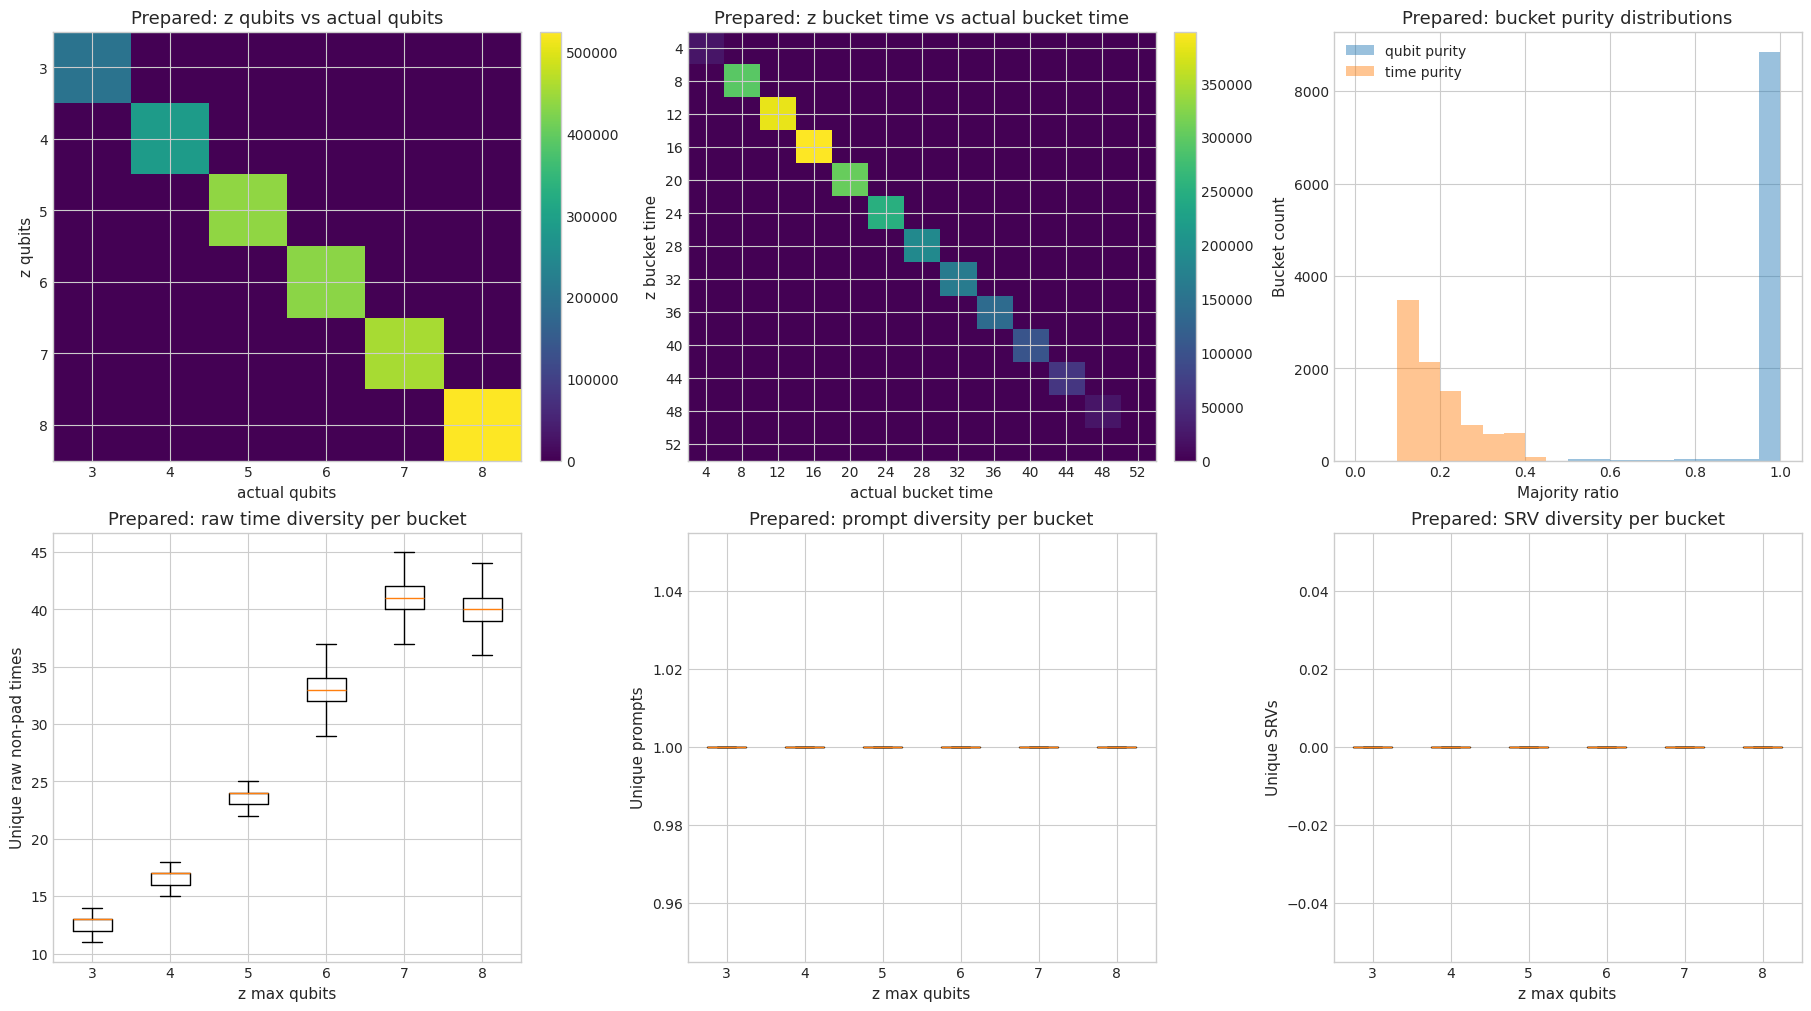

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

plot_pair_heatmap(
    prepared_q_pair_df,
    title="Prepared: z qubits vs actual qubits",
    xlabel="actual qubits",
    ylabel="z qubits",
    ax=axes[0, 0],
)
plot_pair_heatmap(
    prepared_t_pair_df,
    title="Prepared: z bucket time vs actual bucket time",
    xlabel="actual bucket time",
    ylabel="z bucket time",
    ax=axes[0, 1],
)
plot_hist_compare(
    {
        "qubit purity": prepared_df["qubit_majority_ratio"],
        "time purity": prepared_df["time_majority_ratio"],
    },
    bins=np.linspace(0, 1, 21),
    title="Prepared: bucket purity distributions",
    xlabel="Majority ratio",
    ax=axes[0, 2],
)

plot_box_by_qubits(
    prepared_df,
    "actual_nonpad_time_unique_count",
    title="Prepared: raw time diversity per bucket",
    ylabel="Unique raw non-pad times",
    ax=axes[1, 0],
)
plot_box_by_qubits(
    prepared_df,
    "prompt_unique_count",
    title="Prepared: prompt diversity per bucket",
    ylabel="Unique prompts",
    ax=axes[1, 1],
)
plot_box_by_qubits(
    prepared_df,
    "srv_unique_count",
    title="Prepared: SRV diversity per bucket",
    ylabel="Unique SRVs",
    ax=axes[1, 2],
)

plt.show()


## Train Split: Exact Stage-2 Training Distribution

/tmp/ipykernel_15648/823483770.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=qubits, showfliers=False)
/tmp/ipykernel_15648/823483770.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=qubits, showfliers=False)
/tmp/ipykernel_15648/823483770.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=qubits, showfliers=False)


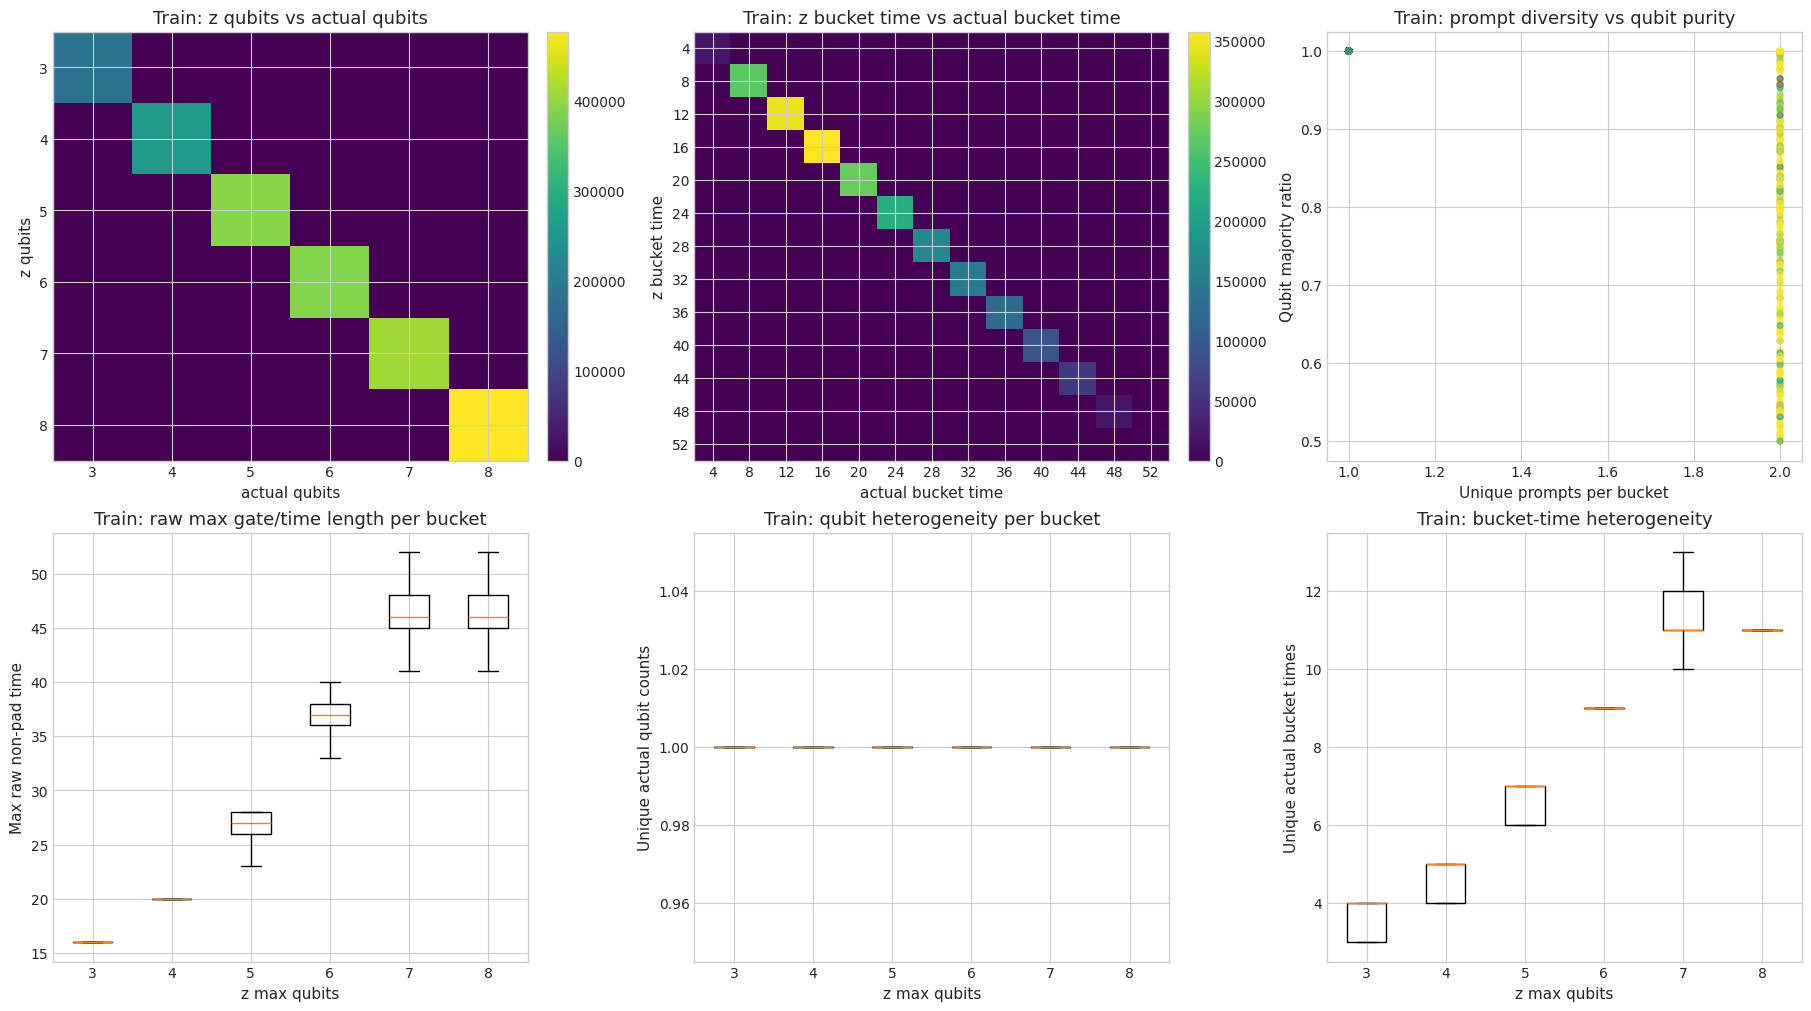

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

plot_pair_heatmap(
    train_q_pair_df,
    title="Train: z qubits vs actual qubits",
    xlabel="actual qubits",
    ylabel="z qubits",
    ax=axes[0, 0],
)
plot_pair_heatmap(
    train_t_pair_df,
    title="Train: z bucket time vs actual bucket time",
    xlabel="actual bucket time",
    ylabel="z bucket time",
    ax=axes[0, 1],
)
axes[0, 2].scatter(
    train_df["prompt_unique_count"],
    train_df["qubit_majority_ratio"],
    c=train_df["z_max_qubits"],
    cmap="viridis",
    alpha=0.5,
    s=18,
)
axes[0, 2].set_title("Train: prompt diversity vs qubit purity")
axes[0, 2].set_xlabel("Unique prompts per bucket")
axes[0, 2].set_ylabel("Qubit majority ratio")

plot_box_by_qubits(
    train_df,
    "actual_nonpad_time_max",
    title="Train: raw max gate/time length per bucket",
    ylabel="Max raw non-pad time",
    ax=axes[1, 0],
)
plot_box_by_qubits(
    train_df,
    "actual_qubits_unique_count",
    title="Train: qubit heterogeneity per bucket",
    ylabel="Unique actual qubit counts",
    ax=axes[1, 1],
)
plot_box_by_qubits(
    train_df,
    "actual_time_unique_count",
    title="Train: bucket-time heterogeneity",
    ylabel="Unique actual bucket times",
    ax=axes[1, 2],
)

plt.show()


## Within-Bucket Circuit Similarity

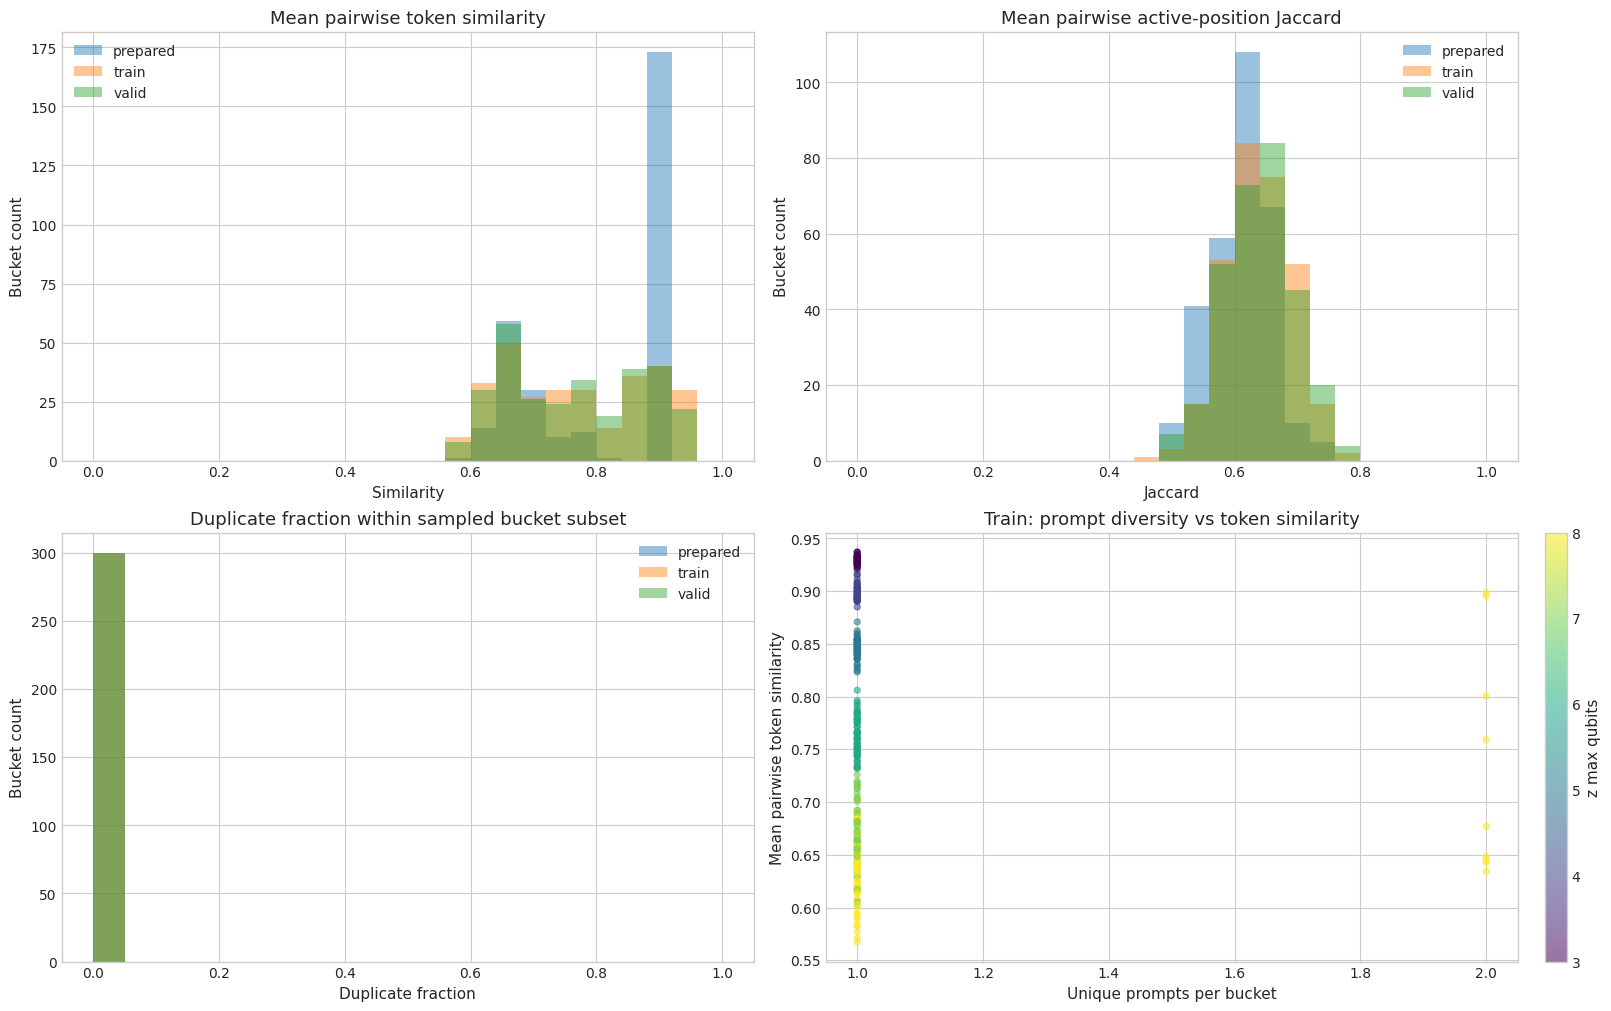

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

plot_hist_compare(
    {
        "prepared": prepared_sim_df["token_similarity_mean"].dropna(),
        "train": train_sim_df["token_similarity_mean"].dropna(),
        "valid": valid_sim_df["token_similarity_mean"].dropna(),
    },
    bins=np.linspace(0, 1, 26),
    title="Mean pairwise token similarity",
    xlabel="Similarity",
    ax=axes[0, 0],
)
plot_hist_compare(
    {
        "prepared": prepared_sim_df["active_jaccard_mean"].dropna(),
        "train": train_sim_df["active_jaccard_mean"].dropna(),
        "valid": valid_sim_df["active_jaccard_mean"].dropna(),
    },
    bins=np.linspace(0, 1, 26),
    title="Mean pairwise active-position Jaccard",
    xlabel="Jaccard",
    ax=axes[0, 1],
)
plot_hist_compare(
    {
        "prepared": prepared_sim_df["duplicate_fraction"].dropna(),
        "train": train_sim_df["duplicate_fraction"].dropna(),
        "valid": valid_sim_df["duplicate_fraction"].dropna(),
    },
    bins=np.linspace(0, 1, 21),
    title="Duplicate fraction within sampled bucket subset",
    xlabel="Duplicate fraction",
    ax=axes[1, 0],
)

sim_train_merged = train_df[["bucket_index", "z_max_qubits", "prompt_unique_count", "srv_unique_count"]].merge(
    train_sim_df, on="bucket_index", how="inner"
)
scatter = axes[1, 1].scatter(
    sim_train_merged["prompt_unique_count"],
    sim_train_merged["token_similarity_mean"],
    c=sim_train_merged["z_max_qubits"],
    cmap="viridis",
    alpha=0.55,
    s=18,
)
axes[1, 1].set_title("Train: prompt diversity vs token similarity")
axes[1, 1].set_xlabel("Unique prompts per bucket")
axes[1, 1].set_ylabel("Mean pairwise token similarity")
plt.colorbar(scatter, ax=axes[1, 1], fraction=0.046, pad=0.04, label="z max qubits")

plt.show()


## Buckets Worth Inspecting

In [10]:
most_heterogeneous = train_df.sort_values(
    ["qubit_majority_ratio", "time_majority_ratio", "prompt_unique_count"],
    ascending=[True, True, False],
).head(20)

most_homogeneous = train_df.sort_values(
    ["qubit_majority_ratio", "time_majority_ratio", "prompt_unique_count"],
    ascending=[False, False, True],
).head(20)

print("MOST HETEROGENEOUS TRAIN BUCKETS")
display(most_heterogeneous[[
    "bucket_index",
    "z_max_qubits",
    "actual_max_qubits",
    "z_max_time",
    "actual_max_time",
    "qubit_majority_ratio",
    "time_majority_ratio",
    "prompt_unique_count",
    "srv_unique_count",
    "ent_bucket_unique_count",
    "actual_qubits_unique_count",
    "actual_time_unique_count",
]])

print("\nMOST HOMOGENEOUS TRAIN BUCKETS")
display(most_homogeneous[[
    "bucket_index",
    "z_max_qubits",
    "actual_max_qubits",
    "z_max_time",
    "actual_max_time",
    "qubit_majority_ratio",
    "time_majority_ratio",
    "prompt_unique_count",
    "srv_unique_count",
    "ent_bucket_unique_count",
    "actual_qubits_unique_count",
    "actual_time_unique_count",
]])


MOST HETEROGENEOUS TRAIN BUCKETS


,bucket_index,z_max_qubits,actual_max_qubits,z_max_time,actual_max_time,qubit_majority_ratio,time_majority_ratio,prompt_unique_count,srv_unique_count,ent_bucket_unique_count,actual_qubits_unique_count,actual_time_unique_count
2976,2976,8,8,48,48,0.500000,0.128906,2,0,0,2,12
949,949,8,8,48,48,0.500000,0.156250,2,0,0,2,12
7985,7985,6,6,40,40,0.500000,0.191406,2,0,0,2,9
2558,2558,7,7,48,48,0.503906,0.140625,2,0,0,2,11
2157,2157,8,8,44,44,0.507812,0.136719,2,0,0,2,10
3338,3338,8,8,48,48,0.507812,0.136719,2,0,0,2,11
314,314,8,8,44,44,0.507812,0.140625,2,0,0,2,11
7197,7197,8,8,48,48,0.507812,0.152344,2,0,0,2,11
4418,4418,8,8,48,48,0.511719,0.128906,2,0,0,2,12
4561,4561,8,8,48,48,0.515625,0.117188,2,0,0,2,11



MOST HOMOGENEOUS TRAIN BUCKETS


,bucket_index,z_max_qubits,actual_max_qubits,z_max_time,actual_max_time,qubit_majority_ratio,time_majority_ratio,prompt_unique_count,srv_unique_count,ent_bucket_unique_count,actual_qubits_unique_count,actual_time_unique_count
4481,4481,3,3,16,16,1.0,0.441406,1,0,0,1,3
8123,8123,3,3,16,16,1.0,0.441406,1,0,0,1,4
1955,1955,3,3,16,16,1.0,0.437500,1,0,0,1,3
7361,7361,3,3,16,16,1.0,0.437500,1,0,0,1,4
699,699,3,3,16,16,1.0,0.433594,1,0,0,1,3
4105,4105,3,3,16,16,1.0,0.433594,1,0,0,1,3
5635,5635,3,3,16,16,1.0,0.429688,1,0,0,1,4
5469,5469,3,3,16,16,1.0,0.425781,1,0,0,1,4
6104,6104,3,3,16,16,1.0,0.425781,1,0,0,1,4
1075,1075,3,3,16,16,1.0,0.421875,1,0,0,1,3


In [11]:
split_purity = pd.DataFrame([
    {
        "split": "prepared",
        "qubit_majority_ratio_p10": prepared_df["qubit_majority_ratio"].quantile(0.10),
        "qubit_majority_ratio_p50": prepared_df["qubit_majority_ratio"].quantile(0.50),
        "time_majority_ratio_p10": prepared_df["time_majority_ratio"].quantile(0.10),
        "time_majority_ratio_p50": prepared_df["time_majority_ratio"].quantile(0.50),
        "prompt_unique_p50": prepared_df["prompt_unique_count"].quantile(0.50),
    },
    {
        "split": "train",
        "qubit_majority_ratio_p10": train_df["qubit_majority_ratio"].quantile(0.10),
        "qubit_majority_ratio_p50": train_df["qubit_majority_ratio"].quantile(0.50),
        "time_majority_ratio_p10": train_df["time_majority_ratio"].quantile(0.10),
        "time_majority_ratio_p50": train_df["time_majority_ratio"].quantile(0.50),
        "prompt_unique_p50": train_df["prompt_unique_count"].quantile(0.50),
    },
    {
        "split": "valid",
        "qubit_majority_ratio_p10": valid_df["qubit_majority_ratio"].quantile(0.10),
        "qubit_majority_ratio_p50": valid_df["qubit_majority_ratio"].quantile(0.50),
        "time_majority_ratio_p10": valid_df["time_majority_ratio"].quantile(0.10),
        "time_majority_ratio_p50": valid_df["time_majority_ratio"].quantile(0.50),
        "prompt_unique_p50": valid_df["prompt_unique_count"].quantile(0.50),
    },
])

display(split_purity)


,split,qubit_majority_ratio_p10,qubit_majority_ratio_p50,time_majority_ratio_p10,time_majority_ratio_p50,prompt_unique_p50
0,prepared,1.0,1.0,0.128906,0.164062,1.0
1,train,1.0,1.0,0.128906,0.164062,1.0
2,valid,1.0,1.0,0.128906,0.164062,1.0
